`conda activate seacells`

In [1]:
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
# import scglue
import os
from matplotlib import rcParams
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
sc.settings.n_jobs = 20

In [3]:
# scglue.plot.set_publication_params()
rcParams["figure.figsize"] = (5, 5)

In [4]:
import warnings
import re

warnings.filterwarnings("ignore", category=UserWarning, message="No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored")

In [5]:
directory = "mosaic_integration_scglue/"
malignant = sc.read(os.path.join(directory, "malignant_embbeding.h5ad"))

/home/cruiz2/miniconda3/envs/seacells/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [12]:
sc.pp.neighbors(malignant, use_rep="X_glue", metric="cosine")

/home/cruiz2/miniconda3/envs/seacells/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/cruiz2/miniconda3/envs/seacells/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/cruiz2/miniconda3/envs/seacells/lib/python3.8/site-packages/

In [13]:
sc.tl.diffmap(malignant)

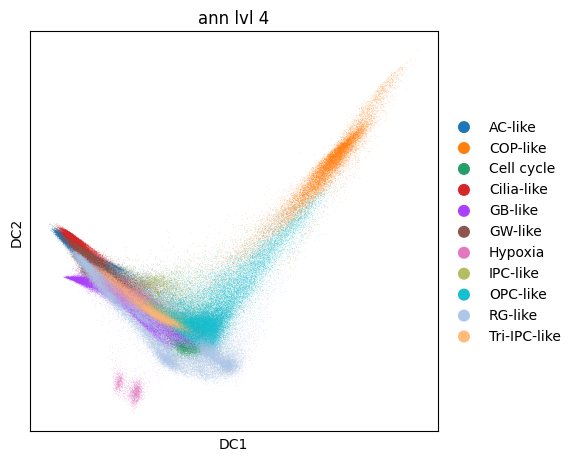

In [14]:
sc.pl.scatter(
    malignant,
    basis="diffmap",
    color=["ann_lvl_4"],
    components=[1, 2],
)

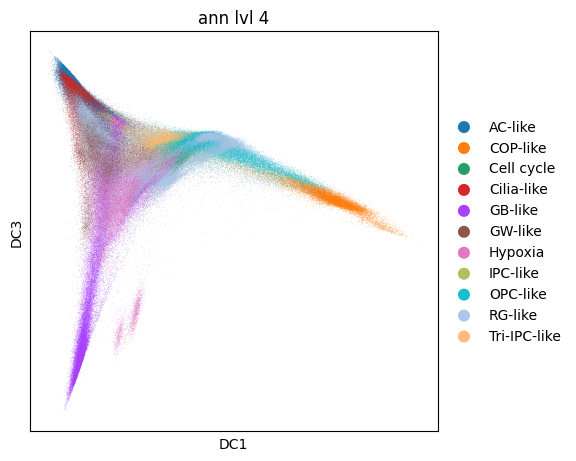

In [15]:
sc.pl.scatter(
    malignant,
    basis="diffmap",
    color=["ann_lvl_4"],
    components=[1, 3],
)

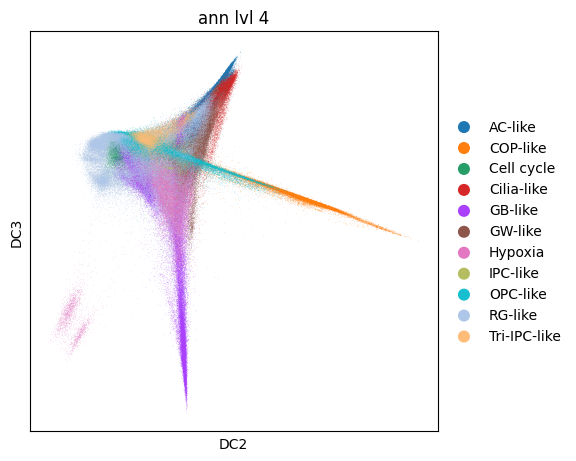

In [16]:
sc.pl.scatter(
    malignant,
    basis="diffmap",
    color=["ann_lvl_4"],
    components=[2, 3],
)

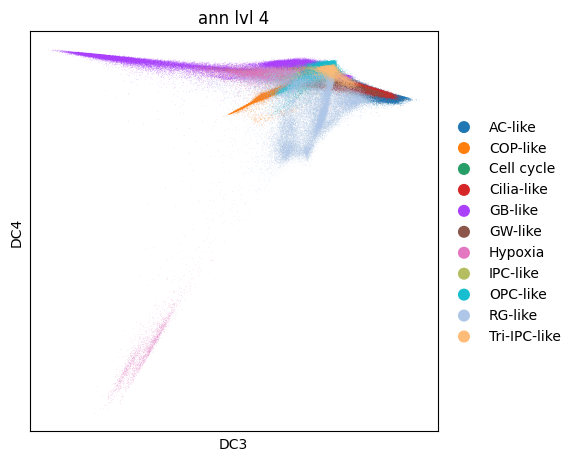

In [17]:
sc.pl.scatter(
    malignant,
    basis="diffmap",
    color=["ann_lvl_4"],
    components=[3, 4],
)

In [18]:
malignant_rna = malignant[(malignant.obs['iCNV'] == 'tumor') & (malignant.obs['domain'] == 'scRNA-seq')].copy()
malignant_rna

AnnData object with n_obs × n_vars = 254854 × 0
    obs: 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Batch_for_correction', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'Survival', 'Survival_months', 'Mitosis', 'Ki67', 'Methylation_array', 'H3F3A', 'H3C3', 'HIST1H3B', 'HIST2H3C', 'TP53', 'EGFR', 'PDGFRA', 'SUFU', 'NF1', 'pTERT', 'PIK3CA', 'PIK3R1', 'ATRX', 'PTEN', 'ASXL1', 'BCOR', 'BCORL1', 'SMC1A', 'WT1', 'PPM1D', 'ACVR1', 'TSHR', 'BRAF', 'GNAQ', 'LMNA', 'KIT', 'ARID1A', 'KRAS', 'Other', 'cell_id', 'modality', 'domain', 'leiden_1', 'leiden_1_3', 'leiden_1_5', 'leiden_1_8', 'leiden_2', 'leiden_2_3', 'leiden_2_5', 'leiden_2_8', 'leiden_3', 'louvain_1', 'louvain_1_3', 'louvain_1_5'

In [19]:
malignant_rna.obsm['X_diffmap'].shape

(254854, 15)

In [20]:
malignant_rna.write('/projects/0/einf2548/cruiz/dmg/data/trajectories/malignant_rna_dm.h5ad')

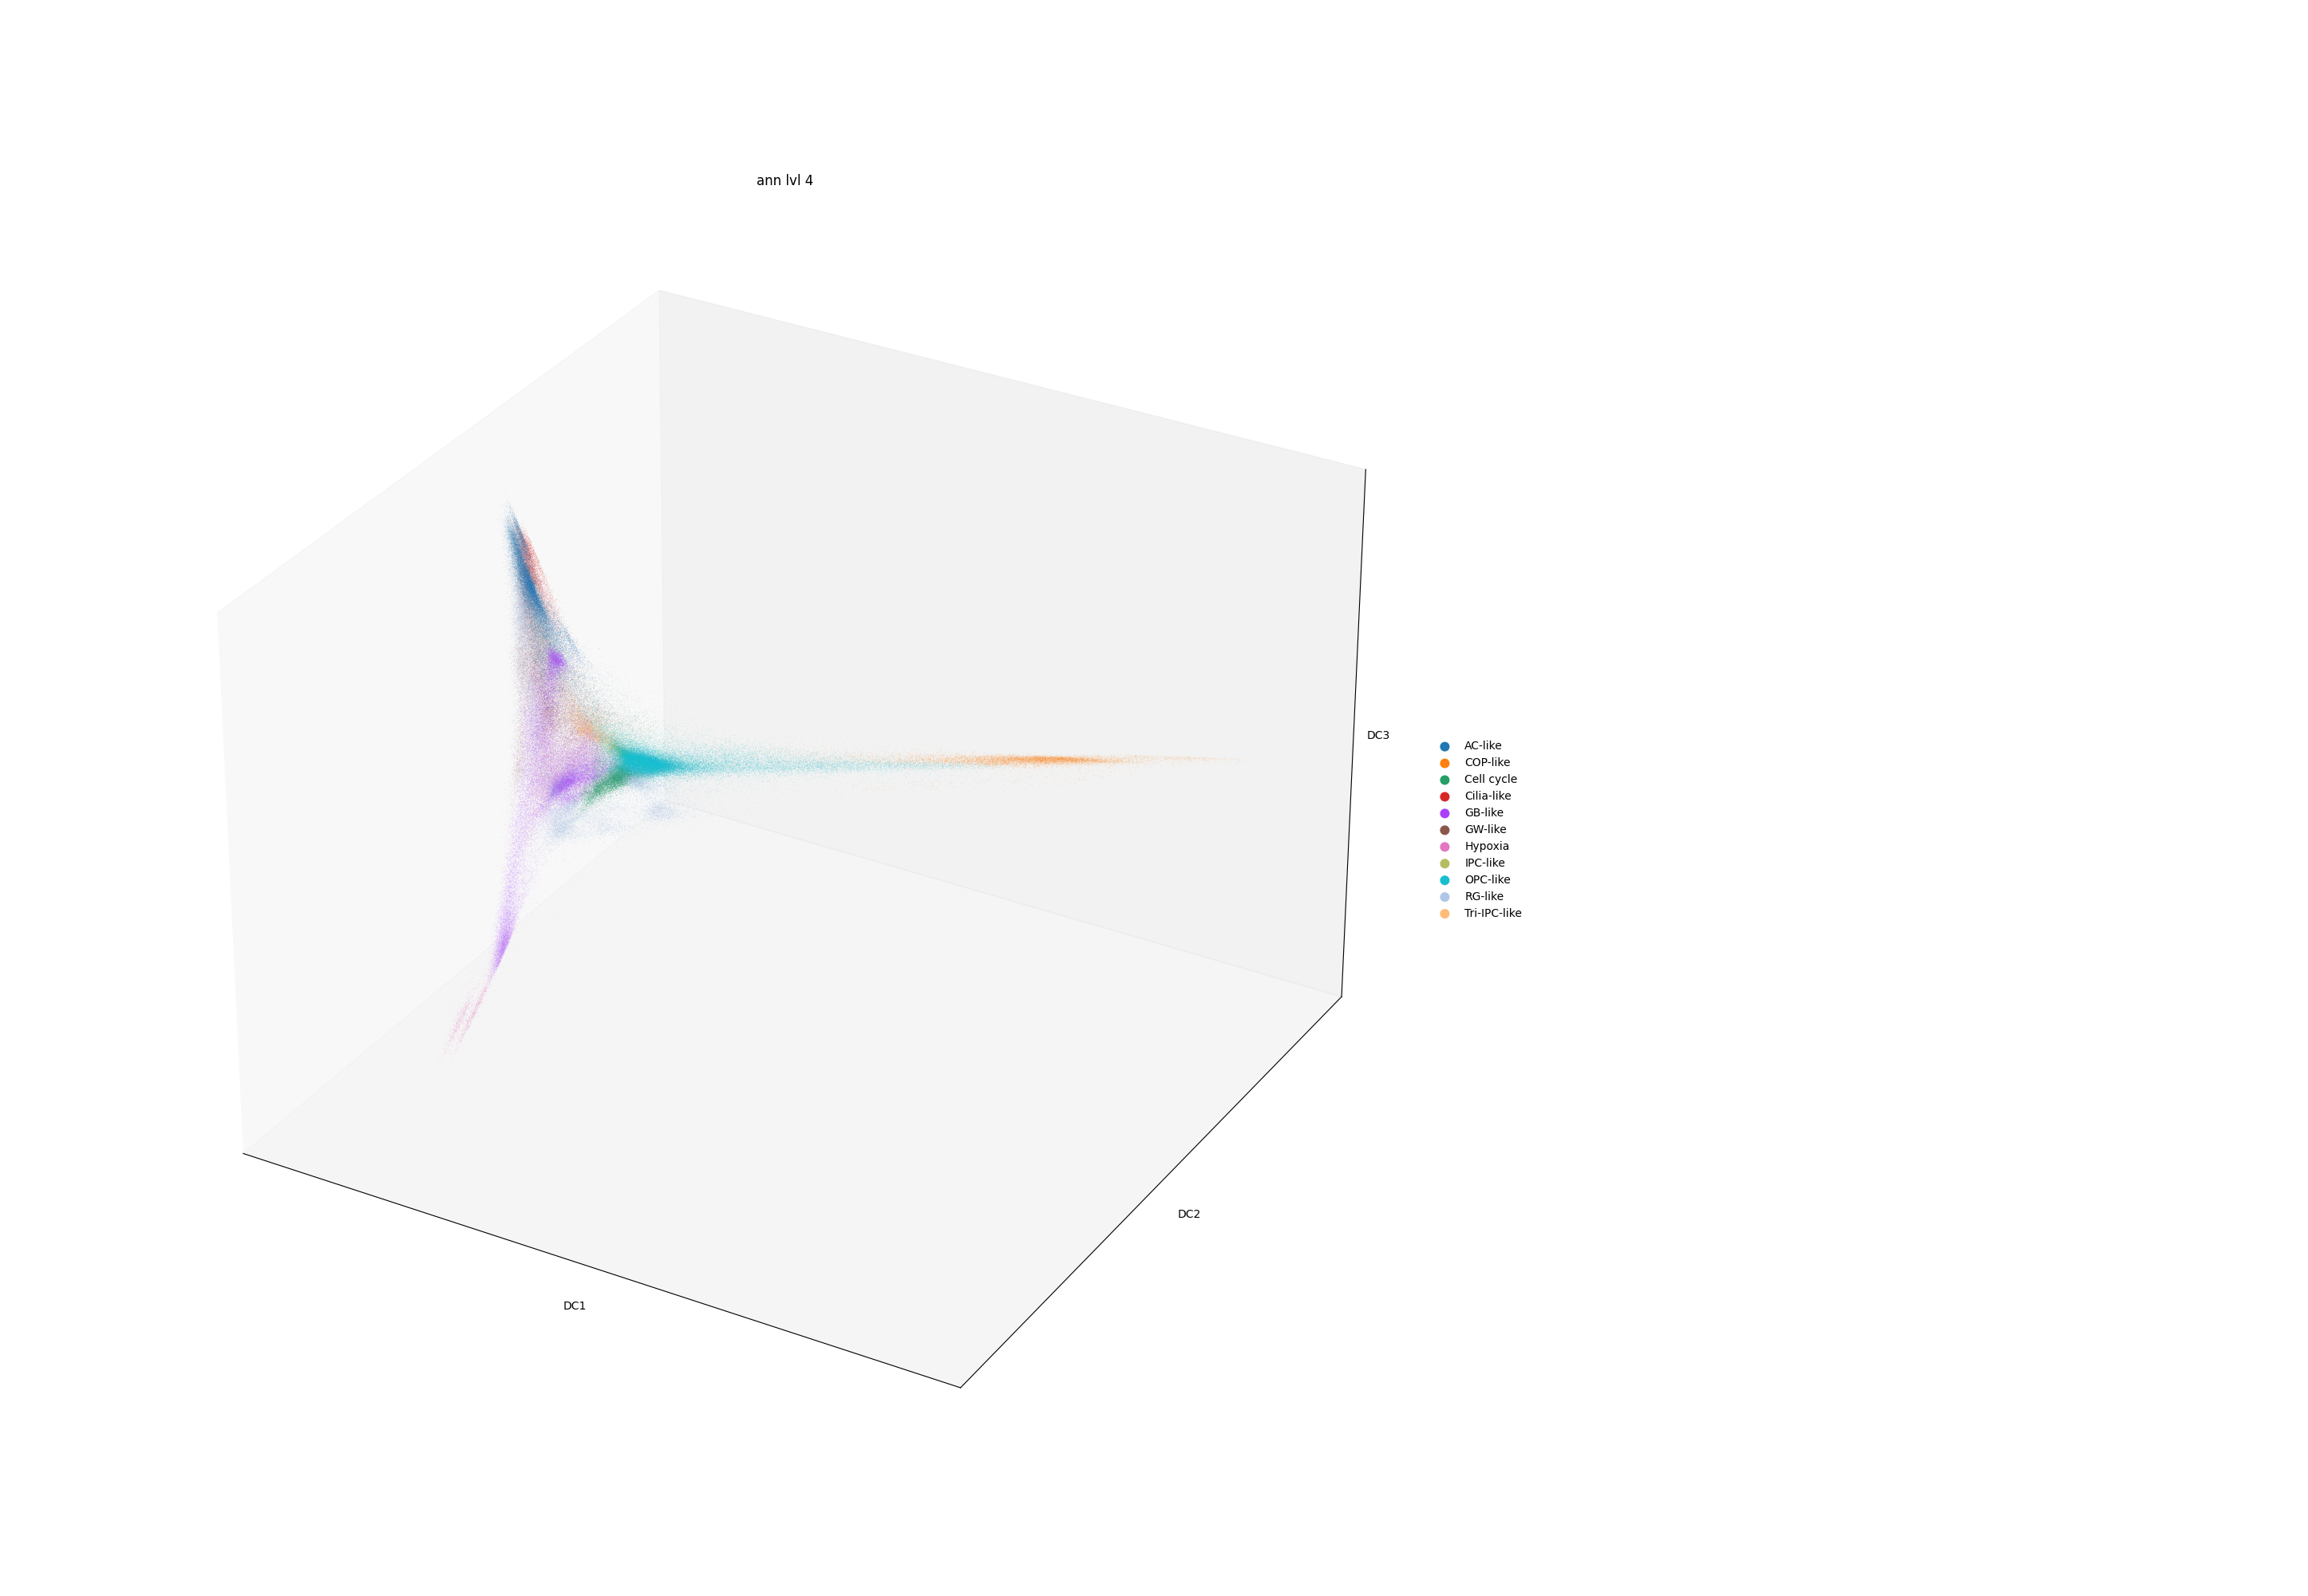

In [10]:
%matplotlib widget
rcParams['figure.figsize'] = 20, 20

sc.pl.scatter(
    adata,
    basis="diffmap",
    color=["ann_lvl_4"],
    projection='3d',
    components=[1, 2, 3],
)